# 0. Importando bibliotecas

In [ ]:
pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tratamento

In [ ]:
path_df_balanco_dia ="dataset_principal/balanco_servico_dia.csv"

df_balanco_dia = pd.read_csv(path_df_balanco_dia)

df_balanco_dia.head()

,data,servico,consorcio,km_apurada,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,versao,datetime_ultima_atualizacao,id_execucao_dbt
0,2024-02-07,SN483,Internorte,526.046,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
1,2024-02-07,313,Internorte,2839.089,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
2,2024-02-07,385,Internorte,119.790,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
3,2024-02-07,920,Internorte,3377.366,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
4,2024-02-07,249,Internorte,5411.151,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e


In [ ]:
df_balanco_dia_tratado = df_balanco_dia.drop(columns=['km_apurada','versao','datetime_ultima_atualizacao','id_execucao_dbt'])
df_balanco_dia_tratado.head()

,data,servico,consorcio,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-02-07,SN483,Internorte,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494
1,2024-02-07,313,Internorte,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479
2,2024-02-07,385,Internorte,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690
3,2024-02-07,920,Internorte,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026
4,2024-02-07,249,Internorte,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161


In [ ]:
path_df_servico_historico = "dataset_principal/sumario_servico_dia_historico.csv"

df_servico_historico = pd.read_csv(path_df_servico_historico)

df_servico_historico.head()

,data,tipo_dia,consorcio,servico,vista,viagens,km_apurada,km_planejada,perc_km_planejada,valor_subsidio_pago,valor_penalidade,datetime_ultima_atualizacao
0,2024-04-06,Sabado,Santa Cruz,383,Realengo - Praça da República,154,5154.242,6056.38,85.10,14980.27260,0.0,2025-09-22 12:32:31.291432
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba - Campo Grande,14,438.038,377.51,116.03,1769.67352,0.0,2025-09-22 12:32:31.291432
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy - Terminal Mato Alto,72,1738.368,1786.66,97.30,7023.00672,0.0,2025-09-22 12:32:31.291432
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto - Santa Cruz,17,297.490,279.71,106.36,990.32740,0.0,2025-09-22 12:32:31.291432
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo - Terminal Campo Grande,38,265.620,231.10,114.94,1073.10480,0.0,2025-09-22 12:32:31.291432


In [ ]:
df_servico_historico[['bairro_inicio', 'bairro_fim']] = df_servico_historico['vista'].str.split('-', expand=True)
df_servico_historico_tratado = df_servico_historico.drop(columns=['datetime_ultima_atualizacao','valor_subsidio_pago','vista'])


In [ ]:
df_final = df_servico_historico_tratado.merge(df_balanco_dia_tratado, on=['servico', 'data','consorcio'], how='inner')

In [ ]:
df_final.head()

,data,tipo_dia,consorcio,servico,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,bairro_inicio,bairro_fim,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,154,5154.242,6056.38,85.10,0.0,Realengo,Praça da República,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,14,438.038,377.51,116.03,0.0,Sepetiba,Campo Grande,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,72,1738.368,1786.66,97.30,0.0,Vila Kennedy,Terminal Mato Alto,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,17,297.490,279.71,106.36,0.0,Terminal Mato Alto,Santa Cruz,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,38,265.620,231.10,114.94,0.0,Cantagalo,Terminal Campo Grande,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [ ]:
# Reorganizando as colunas para melhorar a leitura

col = df_final.pop('bairro_inicio')
df_final.insert(4, 'bairro_inicio', col)

col = df_final.pop('bairro_fim')
df_final.insert(5, 'bairro_fim', col)


In [ ]:
df_final.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,Realengo,Praça da República,154,5154.242,6056.38,85.10,0.0,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba,Campo Grande,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,0.0,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,0.0,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,0.0,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [ ]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 60143 entries, 0 to 60142
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   data                        60143 non-null  str    
 1   tipo_dia                    60143 non-null  str    
 2   consorcio                   60143 non-null  str    
 3   servico                     60143 non-null  str    
 4   bairro_inicio               60143 non-null  str    
 5   bairro_fim                  60143 non-null  str    
 6   viagens                     60143 non-null  int64  
 7   km_apurada                  60143 non-null  float64
 8   km_planejada                60143 non-null  float64
 9   perc_km_planejada           60143 non-null  float64
 10  valor_penalidade            60143 non-null  float64
 11  receita_total_esperada      59771 non-null  float64
 12  receita_tarifaria_esperada  60143 non-null  float64
 13  subsidio_esperado           59771 non-null

### 1.1 Tratamento de nulos

In [ ]:
df_final[df_final.isnull().any(axis=1)]

In [ ]:
df_final = df_final.dropna().reset_index(drop=True)

In [ ]:
df_final.info()


<class 'pandas.DataFrame'>
RangeIndex: 59771 entries, 0 to 59770
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   data                        59771 non-null  datetime64[us]
 1   tipo_dia                    59771 non-null  str           
 2   consorcio                   59771 non-null  str           
 3   servico                     59771 non-null  str           
 4   bairro_inicio               59771 non-null  str           
 5   bairro_fim                  59771 non-null  str           
 6   viagens                     59771 non-null  int64         
 7   km_apurada                  59771 non-null  float64       
 8   km_planejada                59771 non-null  float64       
 9   perc_km_planejada           59771 non-null  float64       
 10  valor_penalidade            59771 non-null  float64       
 11  receita_total_esperada      59771 non-null  float64       
 12  r

# 2. Análise gráfica dos dados

In [ ]:
# Calcula o total do saldo por serviço
total_balanco = df_final.groupby('servico')['saldo'].sum()

# Pega os índices dos 5 maiores serviços lucrativos
top5 = total_balanco.nlargest(5).index

# PegPega os índices dos 5 maiores serviços que dão prejuízo 
worst5 = total_balanco.nsmallest(5).index

# Cria uma lista com os 5 mais lucrativos e 5 desvantajosos
selecionar_servicos = list(top5) + list(worst5)

# Filtra o dataset apenas para mostrar esses serviços
df_final_melhores_piores = df_final[df_final['servico'].isin(selecionar_servicos)]

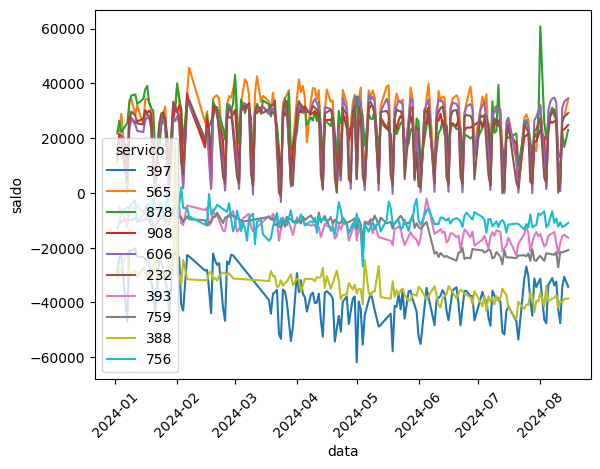

In [ ]:
# Plota a um série temporal do tempo pelo saldo dos serviços

df_final_melhores_piores['data'] = pd.to_datetime(df_final_melhores_piores['data'])

sns.lineplot(data=df_final_melhores_piores, x='data', y='saldo', hue='servico')

plt.xticks(rotation=45)
plt.show()

In [ ]:
# Calcula o total do saldo por serviço
total_subsidio_glosado = df_final.groupby('servico')['subsidio_glosado'].sum()

# Pega os índices dos 5 maiores serviços lucrativos
top5 = total_subsidio_glosado.nlargest(5).index

selecionar_servicos = list(top5) + list(worst5)

# Filtra o dataset apenas para mostrar esses serviços
df_final_maiores_subsidios_glosados = df_final[df_final['servico'].isin(selecionar_servicos)]

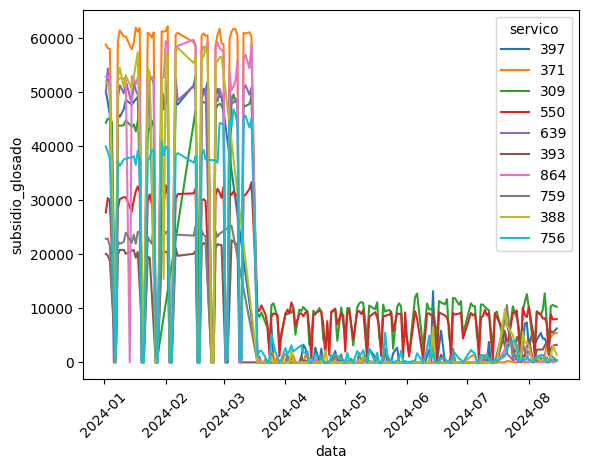

In [ ]:
df_final_maiores_subsidios_glosados['data'] = pd.to_datetime(df_final_maiores_subsidios_glosados['data'])

sns.lineplot(data=df_final_maiores_subsidios_glosados, x='data', y='subsidio_glosado', hue='servico')

plt.xticks(rotation=45)
plt.show()

In [ ]:
df_final['servico'].unique()

<StringArray>
[   '383',  'SN898',    '853',  'SN885',    '845',    '884',    '849',
    '847',  'SV790',    '822',
 ...
    '826', 'LECD95',    '791',    '754',    '737', 'LECD92', 'LECD85',
 'LECD99', 'LECD97', 'LECD98']
Length: 438, dtype: str

### 2.1 Verificar se linhas fantasmas foram contabilizadas nos dados

fonte: https://extra.globo.com/noticias/rio/moradores-sofrem-com-onibus-fantasmas-na-zona-oeste-rv1-1-23836888.html

In [ ]:
linhas_fantasmas = ['358','365','366','388','395','398','364','389','739','744','751','767','874','933']

for servico in linhas_fantasmas:
    if(servico in df_final['servico'].values):
        print(servico)

388
395
389


Dado que o serviço 388 é listado no gráfico de maiores subsídios glosados e há relatos de 2019 que esse serviço operava como linha fantasma, é bem provável que essa linha não tenha melhorado até o período de 2024-2025, e possívelmente até hoje, atuando como um serviço fraudulento para tentativa de captar subsídios.

# 3. Pré-processamento

# 4. Analisando correlação entre as features

# 5. Treinamento do modelo

### 5.1 Dummy

### 5.2 Regressão linear

# TODO
~~1. Plotar um gráfico para series temporais comparando o saldo pelo tempo~~

~~2. Plotar um gráfico de subsidio_glosado e tentar verificiar anomalidades e fraudes em serviços (possíveis linhas fantasmas)~~

3. Tentar achar uma relação entre linhas de ônibus onde o km_apurado é muito alto e possíveis problemas de passagem no csv trajeto alternativo

4. Cruzar dados de chuvas intensas e os dias, e verificar se tem um impacto direto nos km_apurados
